# Letterboxd Movie Ratings Analysis

This notebook explores a personal movie dataset collected from Letterboxd.

Each row represents a movie I have watched and rated. The dataset reflects my personal preferences, not global trends.

To make the analysis more meaningful, I expanded the dataset by adding:
- Genres (multi-label, one-hot encoded)
- Runtime
- Average User Rating

The goal is to understand what drives my movie ratings and whether my taste can be modeled using data.

In [82]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## Loading the Dataset

We begin by loading the dataset and inspecting its structure.

The dataset includes:
- Movie name and release year
- Personal rating
- Genres, runtime, and average user rating

This gives us a mix of categorical and numerical features to work with.

In [59]:
df = pd.read_csv('../data/ratings.csv')

print(df.head(),"\n")
print(df.info(),"\n")
print(df.describe())

         Date               Name  Year        Letterboxd URI  Rating  \
0  2020-10-15           Whiplash  2014  https://boxd.it/7bQA     5.0   
1  2020-10-15         Your Name.  2016  https://boxd.it/cUqs     5.0   
2  2020-10-15    The Dark Knight  2008  https://boxd.it/2b0k     5.0   
3  2020-10-15      Black Panther  2018  https://boxd.it/8MHs     4.0   
4  2020-10-15  Avengers: Endgame  2019  https://boxd.it/9vE4     4.5   

                             Genres  Runtime  Average Rating  
0              Drama-Music-Thriller    107.0            4.42  
1           Animation-Romance-Drama    106.0            4.23  
2             Action-Crime-Thriller    152.0            4.49  
3  Action-Adventure-Science Fiction    135.0            3.70  
4  Adventure-Science Fiction-Action    181.0            3.96   

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1005 entries, 0 to 1004
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          -------------- 

## Data Cleaning and Preparation

Before analysis, the dataset needs to be cleaned.

Steps performed:
- Removed rows with missing values
- Split the `Genres` column into multiple categories
- One-hot encoded genres for machine learning models

After this step, each movie is represented as a numerical feature vector.

In [60]:
df.isnull().sum()
df = df.dropna()

In [61]:
encoded_df = df['Genres'].str.get_dummies(sep='-')
df = df.join(encoded_df).drop(columns=['Genres'])
print(df.head())

         Date               Name  Year        Letterboxd URI  Rating  Runtime  \
0  2020-10-15           Whiplash  2014  https://boxd.it/7bQA     5.0    107.0   
1  2020-10-15         Your Name.  2016  https://boxd.it/cUqs     5.0    106.0   
2  2020-10-15    The Dark Knight  2008  https://boxd.it/2b0k     5.0    152.0   
3  2020-10-15      Black Panther  2018  https://boxd.it/8MHs     4.0    135.0   
4  2020-10-15  Avengers: Endgame  2019  https://boxd.it/9vE4     4.5    181.0   

   Average Rating  Action  Adventure  Animation  ...  History  Horror  Music  \
0            4.42       0          0          0  ...        0       0      1   
1            4.23       0          0          1  ...        0       0      0   
2            4.49       1          0          0  ...        0       0      0   
3            3.70       1          1          0  ...        0       0      0   
4            3.96       1          1          0  ...        0       0      0   

   Mystery  Romance  Science Fic

## Exploratory Analysis

We start by visualizing relationships in the data.

Questions explored:
- Do my ratings change over time?
- Do I agree with average user ratings?
- Are there visible trends in how I rate movies?

These plots help identify patterns before applying models.

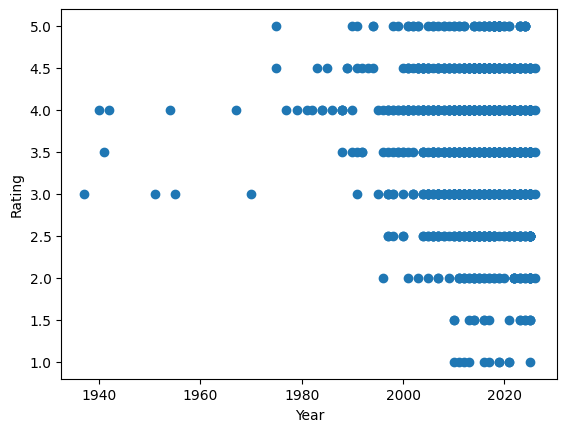

In [62]:
plt.scatter(df["Year"], df["Rating"])
plt.xlabel("Year")
plt.ylabel("Rating")
plt.show()

## Personal vs Average Ratings

This section compares my ratings with the average user ratings.

The goal is to understand:
- Whether I follow general audience opinion
- Or rate movies independently

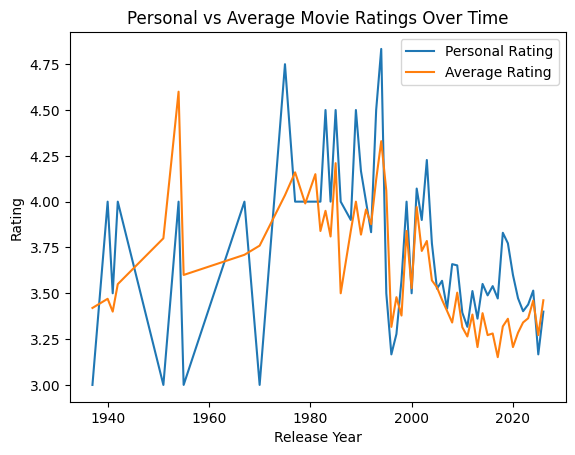

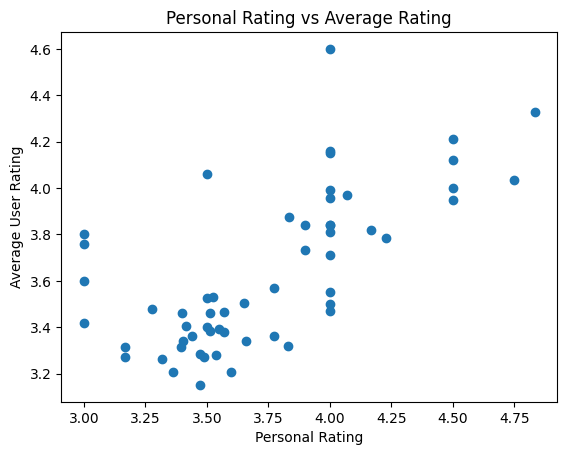

In [63]:
df_grouped = df.groupby('Year')[['Rating', 'Average Rating']].mean().reset_index()
df_grouped = df_grouped.sort_values(by='Year')

plt.figure()

plt.plot(df_grouped['Year'], df_grouped['Rating'], label='Personal Rating')
plt.plot(df_grouped['Year'], df_grouped['Average Rating'], label='Average Rating')

plt.xlabel('Release Year')
plt.ylabel('Rating')
plt.title('Personal vs Average Movie Ratings Over Time')
plt.legend()

plt.show()

plt.scatter(df_grouped["Rating"], df_grouped["Average Rating"])
plt.xlabel("Personal Rating")
plt.ylabel("Average User Rating")
plt.title("Personal Rating vs Average Rating")
plt.show()

A regression line helps quantify this relationship.

Here we fit a linear regression to quantify how well my personal ratings predict the
community average. The model yields an R² of **0.385** — modest, but notably higher than
any genre-based model managed. This tells us something interesting: **how much I like a
movie is a better signal of its general quality than what genre it belongs to.**

The slope of ~0.48 is also worth noting — for every 1 star increase in my rating, the
community average only rises by about half a star. My ratings are simply more extreme
than the crowd's.

Slope: 0.47544681330000077
Intercept: 1.841246515447325
MSE: 0.09933227845289516
R² Score: 0.38544335030839283


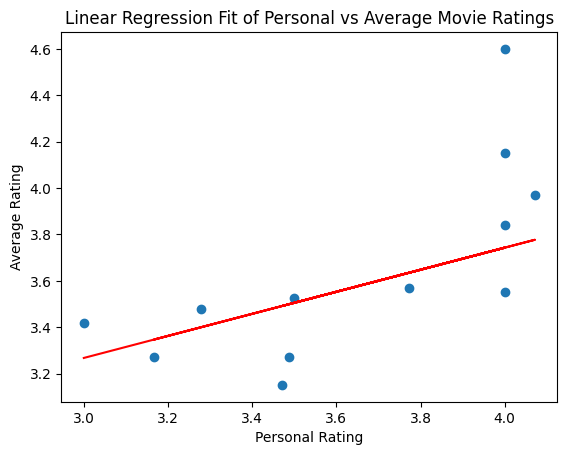

In [81]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

X = df_grouped['Rating'].values.reshape(-1, 1)
y = df_grouped['Average Rating'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

print("Slope:", model.coef_[0])
print("Intercept:", model.intercept_)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("R² Score:", r2)

plt.scatter(X_test, y_test, label="Actual")
plt.plot(X_test, y_pred, color="red", label="Regression Line")
plt.xlabel('Personal Rating')
plt.ylabel('Average Rating')
plt.title('Linear Regression Fit of Personal vs Average Movie Ratings')
plt.show()

In [65]:
print(df_grouped.head())

   Year  Rating  Average Rating
0  1937     3.0            3.42
1  1940     4.0            3.47
2  1941     3.5            3.40
3  1942     4.0            3.55
4  1951     3.0            3.80


## Predicting User's Rating using only Genre and Runtime data

Now we attempt to predict my personal rating for a movie using only its genre and runtime.
The average user rating is excluded to avoid data leakage — the goal is to see whether
metadata alone can capture my taste. A low R² here would suggest my ratings are more
personal than genre patterns can explain.

MAE: 0.7463374846664206
RMSE: 0.907075677530538
R² Score: 0.011635420490268777


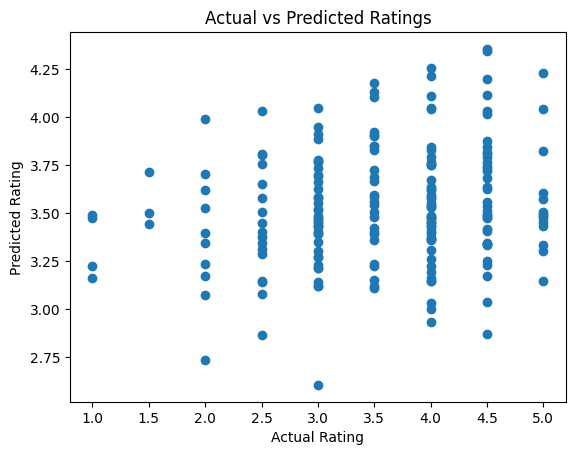

In [80]:
X = df.drop(columns=[
    'Date',
    'Name',
    'Letterboxd URI',
    'Average Rating',
    'Rating'   # target
])

y = df['Rating']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")
plt.title("Actual vs Predicted Ratings")
plt.show()

## What Drives My Ratings? (Linear Model Coefficients)

The model above performed poorly (R² ≈ 0.01), which already tells us something important:
**genre and runtime alone cannot reliably predict my personal ratings.** Taste is more nuanced than any simple linear combination of features.

That said, the coefficients still reveal my directional preferences:

- **Genres I tend to rate higher:** Documentary, Music, Mystery, Animation, and War films
  carry positive weights — suggesting I reward films in these categories more generously.
- **Genres I tend to rate lower:** TV Movies have by far the most negative weight (−0.87),
  followed by Romance (−0.39) and Action (−0.35).

> **Note:** These weights reflect correlation, not causation. I likely seek out documentaries
> and music films I already expect to enjoy, which inflates those coefficients.

            Feature    Weight
7       Documentary  0.492911
13            Music  0.437263
14          Mystery  0.403099
4         Animation  0.298456
19              War  0.290701
6             Crime  0.258239
8             Drama  0.156834
11          History  0.086739
3         Adventure  0.052207
20          Western  0.037157
16  Science Fiction  0.029230
1           Runtime  0.002158
0              Year -0.011747
18         Thriller -0.053809
5            Comedy -0.145527
12           Horror -0.210511
10          Fantasy -0.213773
9            Family -0.240392
2            Action -0.350895
15          Romance -0.392193
17         TV Movie -0.866581


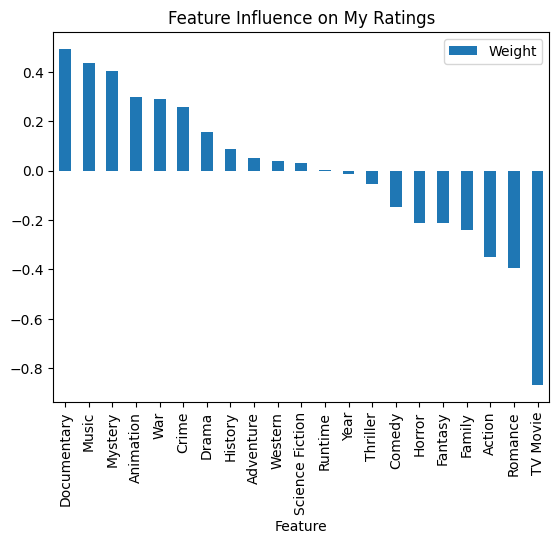

In [67]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Weight': model.coef_
}).sort_values(by='Weight', ascending=False)

print(coefficients)

coefficients.set_index('Feature').plot(kind='bar')
plt.title("Feature Influence on My Ratings")
plt.show()

## Trying a Non-Linear Model: Random Forest

Since linear regression failed to capture meaningful patterns, a **Random Forest Regressor**
is a natural next step. It can model non-linear relationships and interactions between genres
without assuming anything about their structure.

The hope is that combinations of features (e.g. a long Crime Drama from the 1970s) might
predict my ratings better than any single feature alone.

In [68]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("RF MAE:", mean_absolute_error(y_test, y_pred_rf))
print("RF R²:", r2_score(y_test, y_pred_rf))

RF MAE: 0.7559595959595958
RF R²: -0.03911043088590138


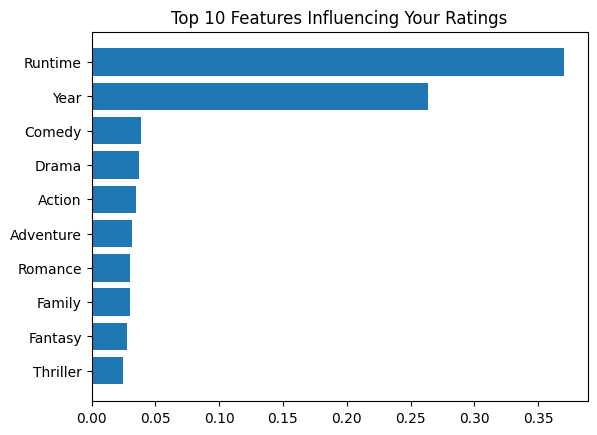

In [69]:
importances = rf.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

top_features = feature_importance_df.head(10)

plt.figure()
plt.barh(top_features['Feature'], top_features['Importance'])
plt.gca().invert_yaxis()
plt.title("Top 10 Features Influencing Your Ratings")
plt.show()

## A Surprising Result: Random Forest Feature Importance

The Random Forest performed even worse than linear regression (R² = −0.039), confirming
that my ratings are genuinely hard to predict from metadata alone.

However, the **feature importance plot reveals something worth examining:** `Runtime` and
`Year` dwarf every genre in importance — by a wide margin. This seems to suggest those two
variables drive my ratings the most.

But this needs scrutiny. Feature importance in Random Forests measures how useful a variable
is for *splitting nodes*, which is influenced by the variable's range and scale. `Runtime`
and `Year` are continuous variables with many possible split points, while genres are binary
(0 or 1) — so continuous variables naturally get inflated importance scores. This is a
known limitation.

To test whether runtime actually predicts my ratings, it's worth isolating it directly.

MAE: 0.7481462876149795
RMSE: 0.9099062452113114
R² Score: 0.005457329796697219


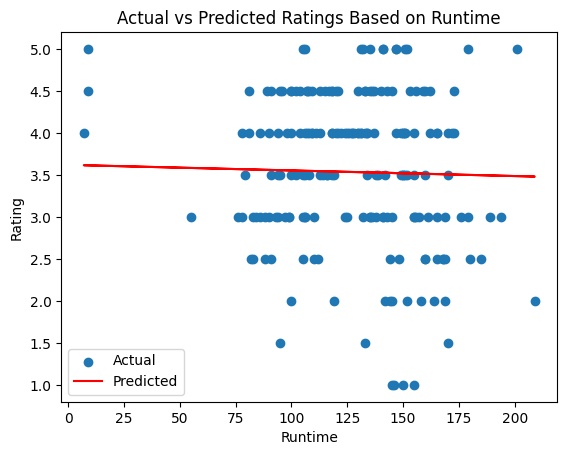

In [70]:
X = df['Runtime']
y = df['Rating']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train.values.reshape(-1, 1), y_train)

y_pred = model.predict(X_test.values.reshape(-1, 1))

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

plt.scatter(X_test, y_test, label="Actual")
plt.plot(X_test, y_pred, label="Predicted", color="red")
plt.xlabel("Runtime")
plt.ylabel("Rating")
plt.title("Actual vs Predicted Ratings Based on Runtime")
plt.legend()
plt.show()

## Clustering My Watch History

Since prediction didn't work well, we shift from supervised to **unsupervised learning**.
The goal here is different — instead of predicting a rating, we want to discover whether
there are natural *groups* of movies in my watch history based on genre, runtime, year,
and rating patterns.

We use **KMeans clustering** with StandardScaler to normalize features first (so runtime
doesn't dominate due to its scale). The **Elbow Method** is used to choose the number of
clusters by plotting inertia against cluster count — we look for the point where adding
more clusters stops providing meaningful gains.

> **Note on results:** The elbow curve does not show a clean inflection point, meaning
> the data does not naturally separate into a small, well-defined number of clusters.
> This is consistent with the earlier finding that my watch history is diverse and
> doesn't follow a rigid pattern. A large number of clusters (75) was ultimately chosen,
> but the resulting groupings are not particularly meaningful or interpretable.
> This is a known limitation of KMeans when applied to sparse, one-hot encoded genre data.

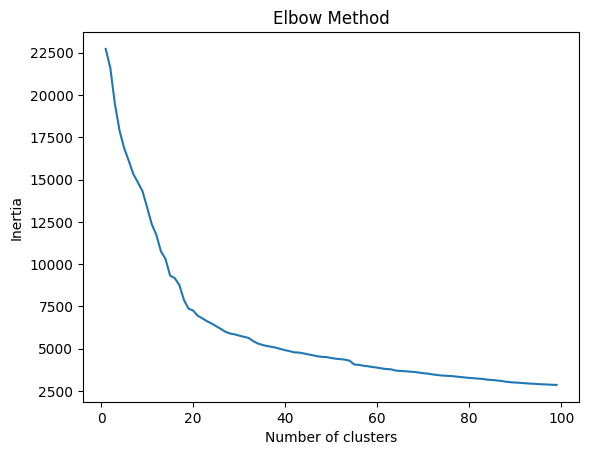

In [71]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

X = df.drop(columns=[
    'Date',
    'Name',
    'Letterboxd URI'
])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

inertia = []

for k in range(1, 100):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 100), inertia)
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

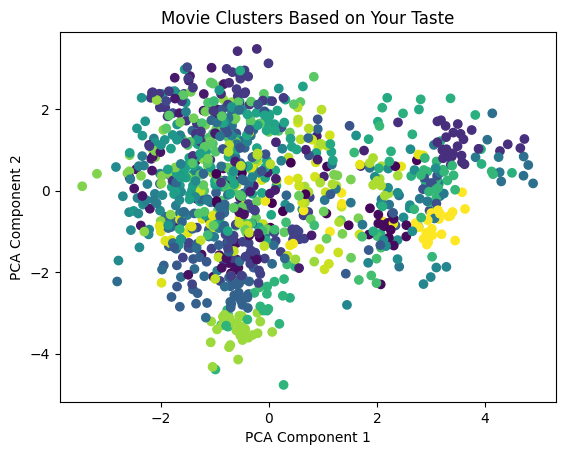

,Year,Rating,Runtime,Average Rating,Action,Adventure,Animation,Comedy,Crime,Documentary,...,History,Horror,Music,Mystery,Romance,Science Fiction,TV Movie,Thriller,War,Western
Cluster,,,,,,,,,,,,,,,,,,,,,
0,2017.500000,2.333333,138.666667,2.742500,0.000000,0.000,0.0,0.250,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2014.750000,4.000000,101.625000,3.722500,0.125000,0.125,1.0,0.125,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,2014.583333,3.125000,91.166667,2.816667,0.000000,1.000,0.0,1.000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2016.250000,4.375000,148.666667,3.891250,0.791667,1.000,0.0,0.000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,2018.615385,3.692308,148.769231,3.319231,1.000000,0.000,0.0,0.000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70,2016.562500,2.843750,144.187500,3.028750,0.750000,0.000,0.0,0.125,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
71,1992.600000,3.900000,97.200000,3.776000,0.000000,0.200,0.6,1.000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
72,2021.333333,3.666667,100.333333,3.603333,0.333333,0.000,0.0,0.000,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [72]:
from sklearn.decomposition import PCA

kmeans = KMeans(n_clusters=75, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['Cluster'])
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Movie Clusters Based on Your Taste")
plt.show()

df.groupby('Cluster')[X.columns.tolist()].mean()

## Movie Recommendation System (KNN-Based)

Since clustering didn't yield clean groupings, we take a more practical approach:
building a **content-based recommendation system** using K-Nearest Neighbors.

The idea is straightforward — given a movie I've already watched, find the *k* most
similar movies in the dataset based on genre profile, runtime, and release year,
then recommend those.

The dataset was originally exported from Letterboxd, which only provides the movie name,
watch date, and personal rating. To make this analysis possible, the dataset was
**expanded and enriched** by adding:
- **Genres** (sourced externally, multi-label, one-hot encoded)
- **Runtime** (in minutes)
- **Average User Rating** (community Letterboxd score)

These additions are what enable both the machine learning models and this recommender
to work at all — without them, there would be no features to learn from.

In [73]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

X = df.drop(columns=[
    'Date',
    'Name',
    'Letterboxd URI',
    'Average Rating',
    'Rating'   # target
])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

knn = NearestNeighbors(n_neighbors=6, metric='euclidean')
knn.fit(X_scaled)

def recommend_movies(movie_name, df, X_scaled, knn, n_recommendations=5):
    
    # Find index of the movie
    idx = df[df['Name'] == movie_name].index[0]
    
    # Get nearest neighbors
    distances, indices = knn.kneighbors([X_scaled[idx]])
    
    # Skip first one (itself)
    similar_indices = indices[0][1:]
    
    recommendations = df.iloc[similar_indices][['Name', 'Rating']]
    
    return recommendations

recommend_movies("Inception", df, X_scaled, knn)

liked_movies = df[df['Rating'] >= 4]

def recommend_from_liked(df, X_scaled, knn, n_recommendations=10):
    
    liked_indices = df[df['Rating'] >= 4].index
    
    recommendations = set()
    
    for idx in liked_indices:
        distances, indices = knn.kneighbors([X_scaled[idx]])
        for i in indices[0][1:]:
            recommendations.add(i)
    
    rec_df = df.iloc[list(recommendations)]
    
    # Remove already watched movies
    rec_df = rec_df[~rec_df.index.isin(liked_indices)]
    
    return rec_df[['Name', 'Average User Rating']].head(n_recommendations)

In [74]:
print("Recommended movies based on Movie A:'Spider-man: Into the Spider-Verse'")
print(recommend_movies("Spider-Man: Into the Spider-Verse", df, X_scaled, knn))
print()
print("Recommended movies based on Movie B:'Superman'")
print(recommend_movies("Dunkirk", df, X_scaled, knn))
print()
print("Recommended movies based on Movie C:'Annihilation'")
print(recommend_movies("Annihilation", df, X_scaled, knn))

Recommended movies based on Movie A:'Spider-man: Into the Spider-Verse'
                                    Name  Rating
98                         Incredibles 2     3.5
545    The Lego Movie 2: The Second Part     3.0
433                    Spies in Disguise     3.5
394                      Kung Fu Panda 3     3.5
698  Spider-Man: Across the Spider-Verse     4.5

Recommended movies based on Movie B:'Superman'
                                    Name  Rating
156              Guardians of the Galaxy     4.5
166  Captain America: The Winter Soldier     4.0
3                          Black Panther     4.0
174       Guardians of the Galaxy Vol. 2     4.5
377                     Ready Player One     4.5

Recommended movies based on Movie C:'Annihilation'
                   Name  Rating
524                Nope     4.0
31          World War Z     3.5
740  Godzilla Minus One     4.0
86   Happy Death Day 2U     3.5
139       A Quiet Place     4.5
